# Seleção de Modelos no IRIS

Atividade individual de Aprendizado de Máquina e Ciência de Dados.

A ideia aqui é treinar 6 classificadores (K-NN, Naive Bayes, Regressão Logística, Árvore de Decisão, MLP e SVM) e fazer a seleção de hiperparâmetros de cada um com busca aleatória (`RandomizedSearchCV`), usando validação cruzada com acurácia. As distribuições de probabilidade de cada hiperparâmetro são as que foram passadas no enunciado.

Separei 20% dos dados como conjunto de teste (hold-out estratificado) e no final avalio cada modelo nesse conjunto com acurácia, precisão e recall.

No final também tem o desafio da fronteira de decisão do melhor modelo numa fatia 2D do dataset.

## 1. Imports e configurações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy.stats import randint, uniform, loguniform, expon

from sklearn.base import clone
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_ITER = 50
N_ITER_MLP = 30
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)

## 2. Dados e Hold-out

O IRIS tem 150 amostras, 4 features e 3 classes com 50 amostras cada. Separei 20% para teste com `stratify=y` para manter a proporção das classes nos dois conjuntos.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names  = list(iris.target_names)

print(f'Shape de X: {X.shape}')
print(f'Features  : {feature_names}')
print(f'Classes   : {dict(zip(target_names, np.bincount(y).tolist()))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
print(f'\nTreino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Distribuição no treino: {np.bincount(y_train).tolist()}')
print(f'Distribuição no teste : {np.bincount(y_test).tolist()}')

Shape de X: (150, 4)
Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes   : {np.str_('setosa'): 50, np.str_('versicolor'): 50, np.str_('virginica'): 50}

Treino: (120, 4) | Teste: (30, 4)
Distribuição no treino: [40, 40, 40]
Distribuição no teste : [10, 10, 10]


## 3. Espaços de busca

Cada modelo recebe as distribuições do enunciado. Os modelos que dependem de distância ou gradiente (KNN, Regressão Logística, MLP e SVM) entram num `Pipeline` com `StandardScaler`, porque sem padronizar as features eles ficam piores. Árvore e Naive Bayes não precisam disso.

Tive que fazer três ajustes pequenos porque o scikit-learn rejeita alguns valores que as distribuições originais podem sortear:

- `min_samples_leaf` como fração só aceita valores até 0.5, então limitei o intervalo
- `max_leaf_nodes` precisa ser pelo menos 2
- o `C` da regressão logística não pode ser exatamente 0, então desloquei o início da uniforme para 1e-10

In [3]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier()),
])
knn_params = {
    'clf__n_neighbors': randint(1, 50),
}

nb_estimator = GaussianNB()

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs')),
])
logreg_params = {
    'clf__C': uniform(loc=1e-10, scale=1e8),
}

tree_estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_params = {
    'min_samples_split': uniform(loc=1e-6, scale=1 - 1e-6),
    'min_samples_leaf': uniform(loc=1e-6, scale=0.5 - 1e-6),
    'max_leaf_nodes': randint(2, 1001),
    'max_depth': randint(1, 1000),
}

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )),
])
mlp_params = {
    'clf__hidden_layer_sizes': randint(1, 100),
    'clf__activation': ['identity', 'logistic', 'tanh'],
    'clf__learning_rate_init': expon(loc=1e-6, scale=0.1),
    'clf__max_iter': randint(1, 1000),
    'clf__momentum': uniform(loc=0.5, scale=0.4999),
}

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=RANDOM_STATE)),
])
svm_params = {
    'clf__C': loguniform(1e-5, 1e5),
    'clf__kernel': ['poly', 'rbf', 'sigmoid'],
    'clf__degree': randint(2, 5),
    'clf__gamma': loguniform(1e-5, 1e5),
}

print('Espaços de busca definidos.')

Espaços de busca definidos.


## 4. Função de tuning

Uma função só para todos os modelos: roda o `RandomizedSearchCV` com 5 folds, acurácia como métrica e `n_jobs=-1` para paralelizar. O `refit=True` já retreina o melhor modelo no treino inteiro no final.

In [4]:
def tune_model(name, estimator, param_dist, n_iter=N_ITER):
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='accuracy',
        cv=CV_FOLDS,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_train, y_train)
    print(f'[{name:>8}] best CV acc = {search.best_score_:.4f}')
    print(f'           params   = {search.best_params_}')
    return search.best_estimator_, search.best_params_, search.best_score_

## 5. Rodando a busca

Para o MLP usei menos iterações (30 em vez de 50) porque cada fit dele demora bem mais. O Naive Bayes não tem o que tunar, então só calculei a acurácia dele em validação cruzada para dar para comparar com os outros.

In [5]:
modelos = [
    ('KNN', knn_pipe, knn_params, N_ITER),
    ('LogReg', logreg_pipe, logreg_params, N_ITER),
    ('Tree', tree_estimator, tree_params, N_ITER),
    ('MLP', mlp_pipe, mlp_params, N_ITER_MLP),
    ('SVM', svm_pipe, svm_params, N_ITER),
]

resultados = {}
for name, est, params, n_iter in modelos:
    best_est, best_params, cv_score = tune_model(name, est, params, n_iter)
    resultados[name] = {
        'best_estimator': best_est,
        'best_params': best_params,
        'cv_score': cv_score,
    }

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
nb_cv = cross_val_score(GaussianNB(), X_train, y_train, cv=skf, scoring='accuracy').mean()
nb_estimator.fit(X_train, y_train)
print(f'[      NB] CV acc      = {nb_cv:.4f}  (sem hiperparâmetros)')
resultados['NaiveBayes'] = {
    'best_estimator': nb_estimator,
    'best_params': {},
    'cv_score': nb_cv,
}

[     KNN] best CV acc = 0.9667
           params   = {'clf__n_neighbors': 12}


[  LogReg] best CV acc = 0.9667
           params   = {'clf__C': np.float64(37454011.88473625)}


[    Tree] best CV acc = 0.9417
           params   = {'max_depth': 958, 'max_leaf_nodes': 688, 'min_samples_leaf': np.float64(0.3091933862805343), 'min_samples_split': np.float64(0.3824626088051714)}


[     MLP] best CV acc = 0.9667
           params   = {'clf__activation': 'identity', 'clf__hidden_layer_sizes': 32, 'clf__learning_rate_init': np.float64(0.09134684129003875), 'clf__max_iter': 243, 'clf__momentum': np.float64(0.5805945214982768)}


[     SVM] best CV acc = 0.9667
           params   = {'clf__C': np.float64(73938.28382876336), 'clf__degree': 2, 'clf__gamma': np.float64(0.0009708604629077593), 'clf__kernel': 'sigmoid'}
[      NB] CV acc      = 0.9500  (sem hiperparâmetros)


## 6. Avaliação no conjunto de teste

Agora cada modelo (já com os melhores hiperparâmetros) é avaliado nos 20% que ficaram de fora. Como o problema tem 3 classes balanceadas, usei média macro para precisão e recall, que dá o mesmo peso para cada classe.

In [6]:
linhas = []
for name, info in resultados.items():
    y_pred = info['best_estimator'].predict(X_test)
    linhas.append({
        'Modelo':          name,
        'CV acc (treino)': info['cv_score'],
        'Acurácia':        accuracy_score(y_test, y_pred),
        'Precisão':        precision_score(y_test, y_pred, average='macro'),
        'Recall':          recall_score(y_test, y_pred, average='macro'),
    })

df = pd.DataFrame(linhas).sort_values('Acurácia', ascending=False).reset_index(drop=True)

df.style \
  .format({c: '{:.4f}' for c in df.columns if c != 'Modelo'}) \
  .background_gradient(subset=['Acurácia', 'Precisão', 'Recall'], cmap='Greens')

,Modelo,CV acc (treino),Acurácia,Precisão,Recall
0,LogReg,0.9667,1.0000,1.0000,1.0000
1,KNN,0.9667,0.9667,0.9697,0.9667
2,NaiveBayes,0.9500,0.9667,0.9697,0.9667
3,SVM,0.9667,0.9667,0.9697,0.9667
4,Tree,0.9417,0.9333,0.9333,0.9333
5,MLP,0.9667,0.8333,0.8498,0.8333


### Matriz de confusão do melhor modelo

Melhor modelo: LogReg
  Hiperparâmetros: {'clf__C': np.float64(37454011.88473625)}
  Acurácia no teste: 1.0000
  Precisão (macro): 1.0000
  Recall (macro): 1.0000


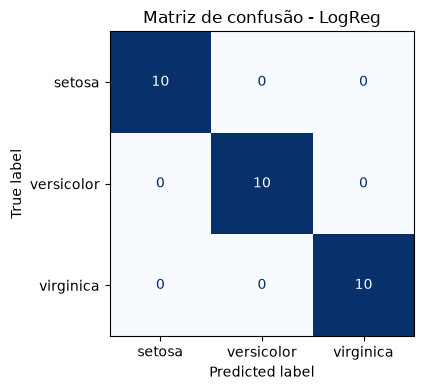

In [7]:
melhor_nome = df.iloc[0]['Modelo']
melhor_modelo = resultados[melhor_nome]['best_estimator']

print(f'Melhor modelo: {melhor_nome}')
print(f'  Hiperparâmetros: {resultados[melhor_nome]["best_params"]}')
print(f'  Acurácia no teste: {df.iloc[0]["Acurácia"]:.4f}')
print(f'  Precisão (macro): {df.iloc[0]["Precisão"]:.4f}')
print(f'  Recall (macro): {df.iloc[0]["Recall"]:.4f}')

y_pred = melhor_modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
    ax=ax, cmap='Blues', colorbar=False,
)
ax.set_title(f'Matriz de confusão - {melhor_nome}')
plt.tight_layout()
plt.show()

## 7. Fronteira de decisão (desafio)

Para conseguir visualizar a fronteira em 2D, peguei só as duas features de pétala (comprimento e largura), que são as que melhor separam as classes, e retreinei o melhor modelo com elas. Daí é só montar um grid de pontos cobrindo o plano, classificar cada ponto e pintar as regiões.

Os círculos são os pontos de treino e os triângulos os de teste.

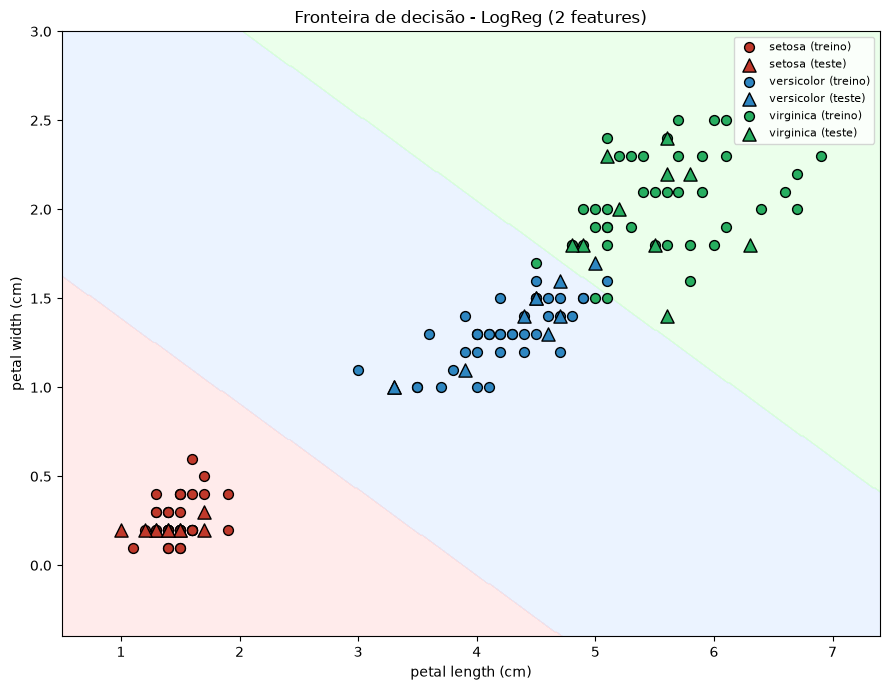

Acurácia do modelo 2D no teste: 0.9667


In [8]:
idx_feat = [2, 3]
X_train_2d = X_train[:, idx_feat]
X_test_2d = X_test[:, idx_feat]

modelo_2d = clone(melhor_modelo)
modelo_2d.fit(X_train_2d, y_train)

x_min, x_max = X[:, idx_feat[0]].min() - 0.5, X[:, idx_feat[0]].max() + 0.5
y_min, y_max = X[:, idx_feat[1]].min() - 0.5, X[:, idx_feat[1]].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500),
)
Z = modelo_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = ListedColormap(['#FFD8D8', '#D8E8FF', '#D8FFD8'])
cmap_pts = ListedColormap(['#C0392B', '#2E86C1', '#27AE60'])

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_bg)

for cls, name in enumerate(target_names):
    mask_tr = y_train == cls
    mask_te = y_test == cls
    plt.scatter(X_train_2d[mask_tr, 0], X_train_2d[mask_tr, 1],
                c=[cmap_pts(cls)], marker='o', s=50, edgecolor='k',
                label=f'{name} (treino)')
    plt.scatter(X_test_2d[mask_te, 0], X_test_2d[mask_te, 1],
                c=[cmap_pts(cls)], marker='^', s=90, edgecolor='k',
                label=f'{name} (teste)')

plt.xlabel(feature_names[idx_feat[0]])
plt.ylabel(feature_names[idx_feat[1]])
plt.title(f'Fronteira de decisão - {melhor_nome} (2 features)')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

acc_2d = accuracy_score(y_test, modelo_2d.predict(X_test_2d))
print(f'Acurácia do modelo 2D no teste: {acc_2d:.4f}')

## 8. Conclusão

A regressão logística ficou em primeiro, acertando os 30 exemplos do teste (acurácia, precisão e recall de 1.0). KNN, MLP e SVM empataram com ela na validação cruzada (0.9667), então esse resultado perfeito no teste tem que ser visto com cuidado: são só 30 amostras, e errar uma única já derruba a acurácia para 0.9667. Ou seja, a diferença entre esses quatro modelos no teste não diz muita coisa.

A árvore de decisão ficou em último na validação cruzada (0.9417). Faz sentido, porque as distribuições do enunciado sorteiam frações altas de `min_samples_split` e `min_samples_leaf` com bastante frequência, o que gera árvores muito rasas. O Naive Bayes, mesmo sem nenhum tuning, ficou com 0.95 de CV, o que mostra como o IRIS é um dataset fácil: a setosa é linearmente separável das outras duas, e versicolor e virginica quase se separam só com as features de pétala.

No plot da fronteira dá para ver exatamente isso: o modelo treinado só com comprimento e largura de pétala já acerta 96.67% do teste, errando basicamente na zona de transição entre versicolor e virginica.

Tudo roda com `RANDOM_STATE=42`, então executar o notebook de novo dá os mesmos números.

Falta ainda (desafio 3 do enunciado): repetir o processo com o dataset do grupo da primeira parte da disciplina.